In [1]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
from pathlib import Path

# Env loading
from dotenv import load_dotenv
import os

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
os.environ["HF_HOME"] = "./models_cache/SAM_original/"

import sys

sys.path.append("..")
from animgen.core.models.model import BaseModelClass

from IPython.display import display

/media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VIEW = 13
MESH_PATH = Path("../generated_data/models/img_mesh_Killer_Whale.glb")
MODEL_PATH = "facebook/sam3"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


In [3]:
# Generating View
mesh = BaseModelClass(MESH_PATH)

view_outputs = mesh.views_output

Rendering Multiviews...: 100%|██████████| 20/20 [00:07<00:00,  2.72it/s]


In [4]:
images = view_outputs["matte"]

In [5]:
# MODEL SETUP
model = Sam3Model.from_pretrained(MODEL_PATH).to(DEVICE)
processor = Sam3Processor.from_pretrained(MODEL_PATH)

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 13342.08it/s]


In [6]:
def to_cpu(obj):
    if torch.is_tensor(obj):
        return obj.cpu()
    elif isinstance(obj, dict):
        return {k: to_cpu(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_cpu(v) for v in obj]
    return obj

In [7]:
prompts = [
    "Tail fin",
    "Top fin",
    "Side fins",
    "Belly fins",
    "Bottom fin near tail"
]

text_embeds_list = []
text_inputs_list = []

for prompt in prompts:
    text_inputs = processor(text=[prompt], return_tensors="pt").to(model.device)

    with torch.no_grad():
        text_embeds = model.get_text_features(**text_inputs)

    attention_mask = text_inputs.attention_mask

    text_embeds_list.append(text_embeds)
    text_inputs_list.append(text_inputs)

In [8]:
from collections import defaultdict

results_dict = defaultdict(list)

with torch.no_grad():
    for image_idx, image in enumerate(images):
        print(f"Processing image {image_idx + 1}/{len(images)}")

        image_inputs = processor(
            images=image,
            return_tensors="pt",
        ).to(model.device)

        vision_embeds = model.get_vision_features(
            pixel_values=image_inputs.pixel_values
        )

        target_sizes = image_inputs["original_sizes"].tolist()

        for text_embeds, text_inputs, prompt in zip(
            text_embeds_list,
            text_inputs_list,
            prompts,
        ):
            outputs = model(
                vision_embeds=vision_embeds,
                text_embeds=text_embeds,
                attention_mask=text_inputs.attention_mask,
            )

            results = processor.post_process_instance_segmentation(
                outputs,
                threshold=0.5,
                mask_threshold=0.5,
                target_sizes=target_sizes,
            )[0]

            semantic_segmentation = {}

            semantic_segmentation = {
                "masks": results["masks"][:2].any(dim=0).cpu().numpy(),
                "image": np.asarray(image),
                "prompt": prompt,
            }

            results_dict[prompt].append(semantic_segmentation)

            del results

        del vision_embeds
        del image_inputs
        


Processing image 1/20
Processing image 2/20
Processing image 3/20
Processing image 4/20
Processing image 5/20
Processing image 6/20
Processing image 7/20
Processing image 8/20
Processing image 9/20
Processing image 10/20
Processing image 11/20
Processing image 12/20
Processing image 13/20
Processing image 14/20
Processing image 15/20
Processing image 16/20
Processing image 17/20
Processing image 18/20
Processing image 19/20
Processing image 20/20


In [9]:
for prompt, results in results_dict.items():
    print("Prompt:", prompt)
    for result in results:
        print("Key:", result.keys())
        print("Mask shape:", result["masks"].shape)
        print("Image shape:", result["image"].shape)
        print("prompt:", result["prompt"])
        break
    print("\n\n")

Prompt: Tail fin
Key: dict_keys(['masks', 'image', 'prompt'])
Mask shape: (1024, 1024)
Image shape: (1024, 1024, 3)
prompt: Tail fin



Prompt: Top fin
Key: dict_keys(['masks', 'image', 'prompt'])
Mask shape: (1024, 1024)
Image shape: (1024, 1024, 3)
prompt: Top fin



Prompt: Side fins
Key: dict_keys(['masks', 'image', 'prompt'])
Mask shape: (1024, 1024)
Image shape: (1024, 1024, 3)
prompt: Side fins



Prompt: Belly fins
Key: dict_keys(['masks', 'image', 'prompt'])
Mask shape: (288, 288)
Image shape: (1024, 1024, 3)
prompt: Belly fins



Prompt: Bottom fin near tail
Key: dict_keys(['masks', 'image', 'prompt'])
Mask shape: (1024, 1024)
Image shape: (1024, 1024, 3)
prompt: Bottom fin near tail





Prompt: Tail fin


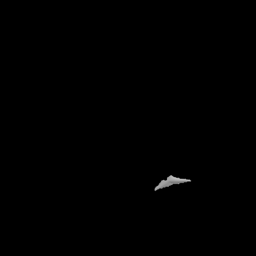

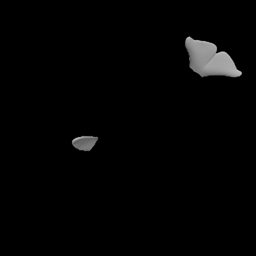

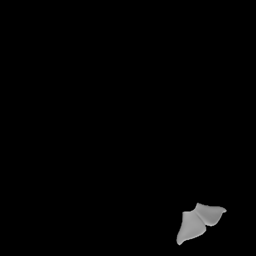

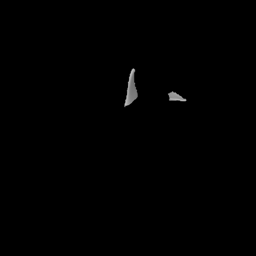

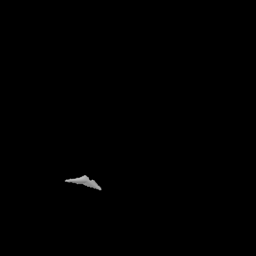

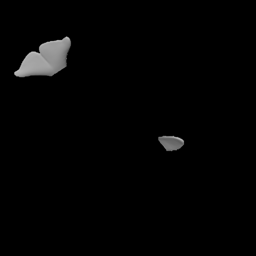

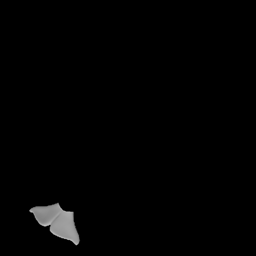

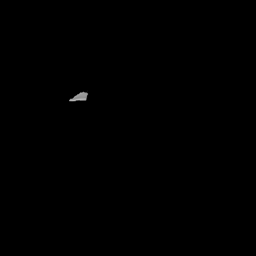

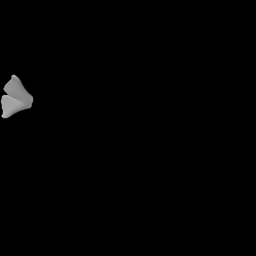

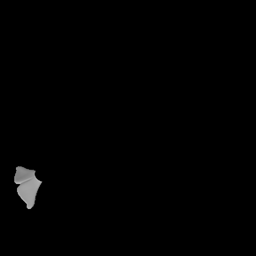

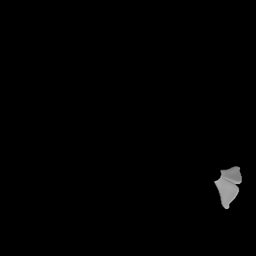

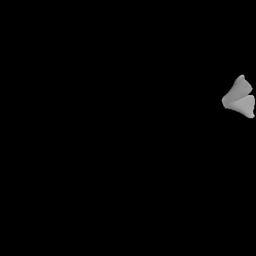

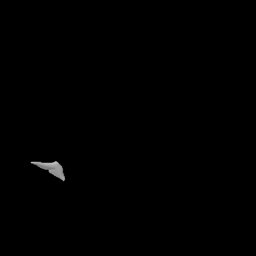

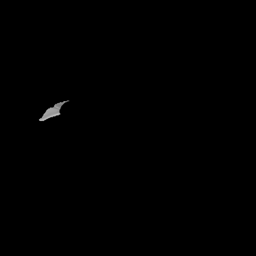

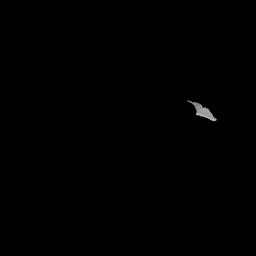

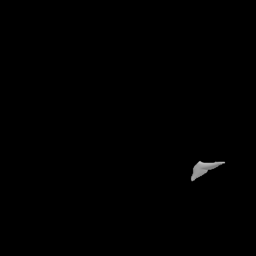

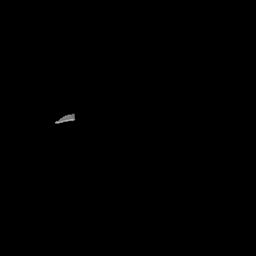

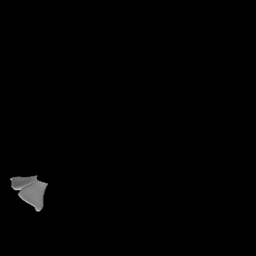

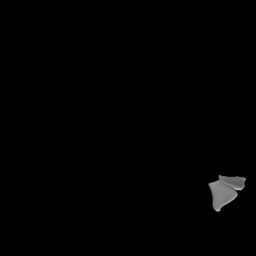

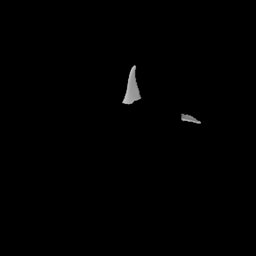

Prompt: Top fin


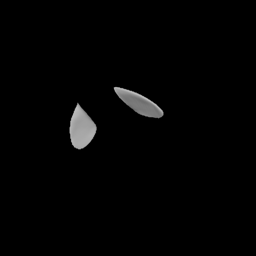

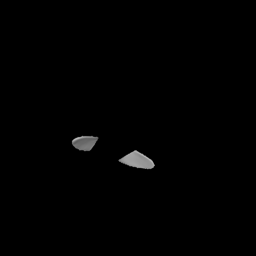

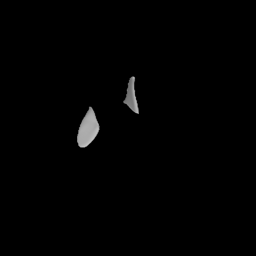

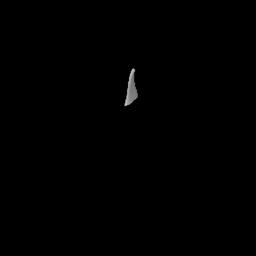

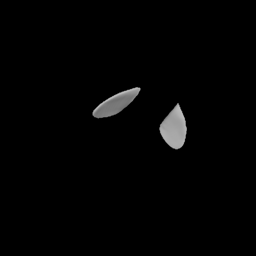

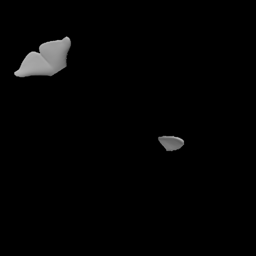

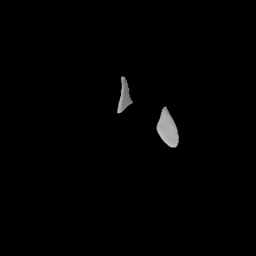

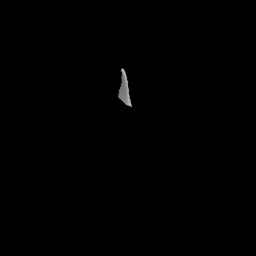

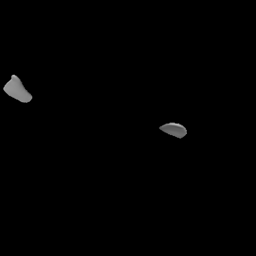

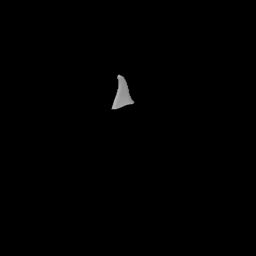

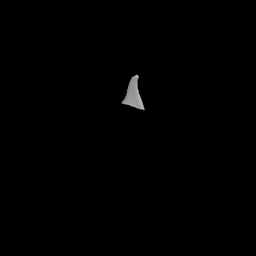

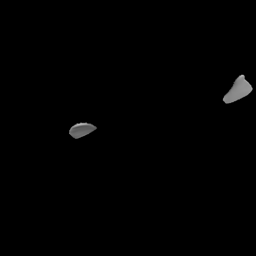

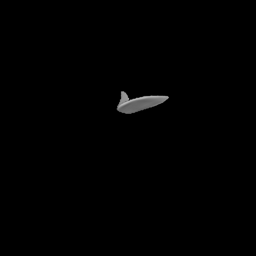

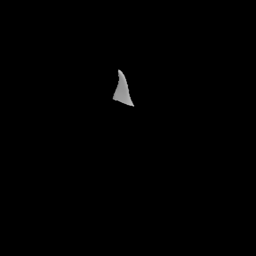

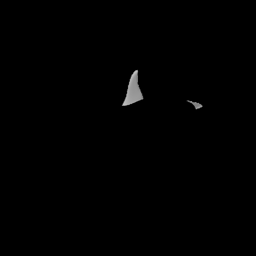

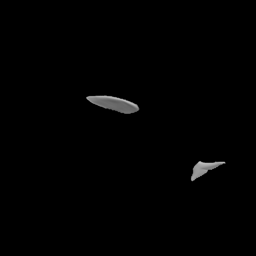

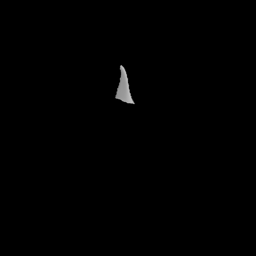

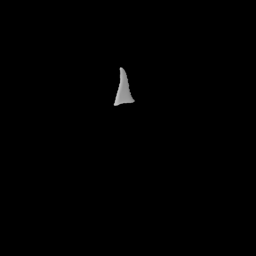

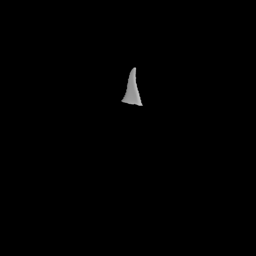

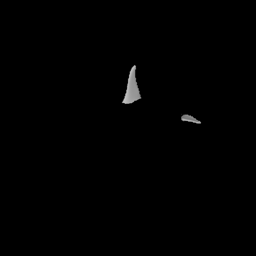

Prompt: Side fins


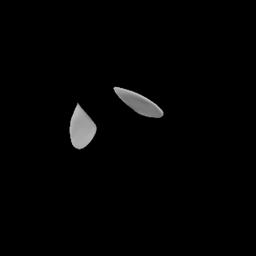

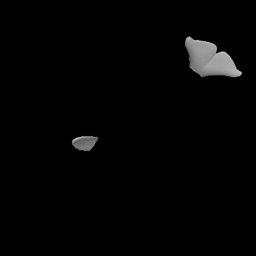

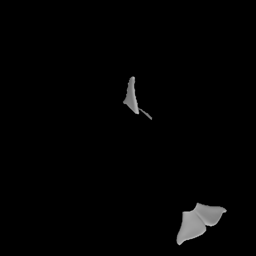

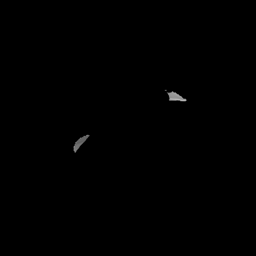

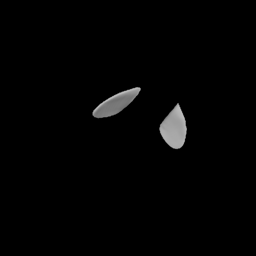

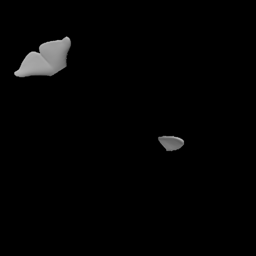

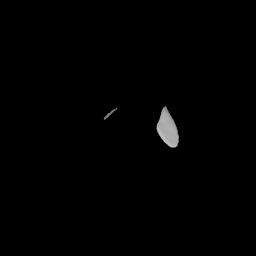

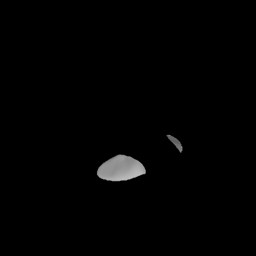

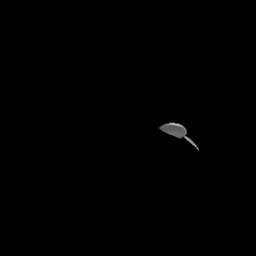

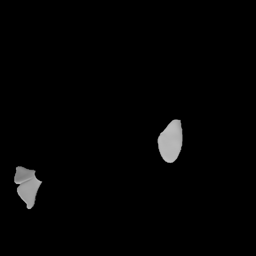

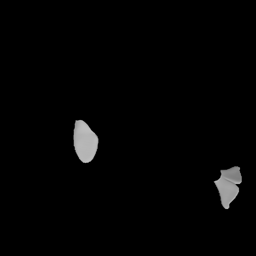

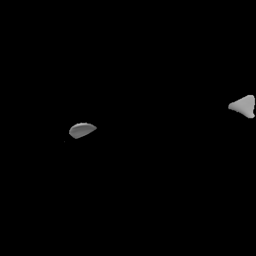

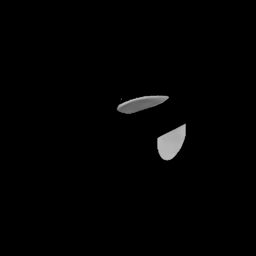

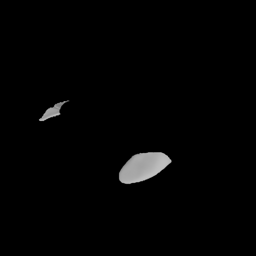

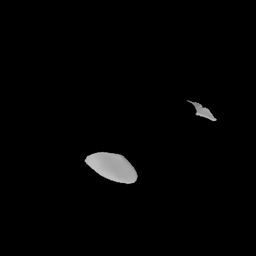

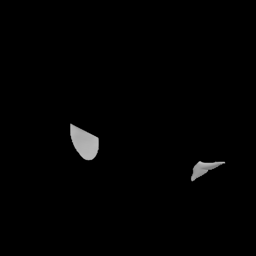

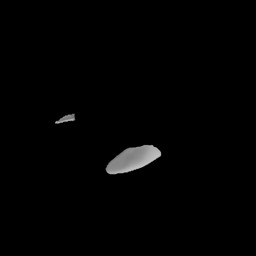

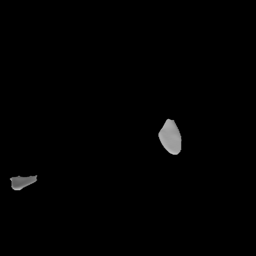

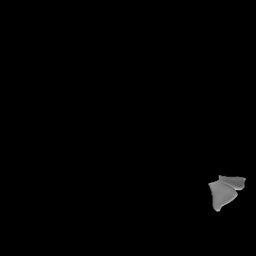

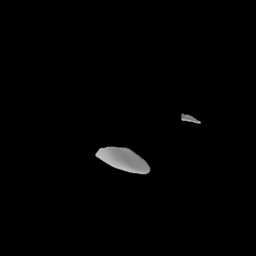

Prompt: Belly fins


ValueError: operands could not be broadcast together with shapes (1024,1024) (288,288) 

In [11]:
for prompt, results in results_dict.items():
    print("Prompt:", prompt)
    for result in results:
        mask = result["masks"]
        image = result["image"]

        if len(mask) == 0:
            print(f"No masks found for prompt '{prompt}'")
            continue

        # Create a new image with the same size as the original
        masked_image = np.zeros_like(image)

        # Apply the mask to each channel of the image
        for c in range(image.shape[2]):
            masked_image[:, :, c] = image[:, :, c] * mask

        # Convert to PIL Image and display
        masked_image_pil = Image.fromarray(masked_image)
        display(masked_image_pil.resize((masked_image_pil.width // 4, masked_image_pil.height // 4)))

In [ ]:
from collections import Counter

selected_faces_per_prompt = {}

for prompt, results in results_dict.items():
    face_votes = Counter()

    for i, result in enumerate(results):
        chosen_mask = result["masks"]
        chosen_faces = view_outputs["faces"][i]

        masked_pixels = chosen_mask > 0

        masked_face_ids = chosen_faces[masked_pixels]
        masked_face_ids = masked_face_ids[masked_face_ids >= 0]

        # Count each face only once per view
        unique_faces = np.unique(masked_face_ids)
        face_votes.update(unique_faces.tolist())

    # Require at least 2 views to agree
    min_votes = 2

    selected_faces_per_prompt[prompt] = np.array(
        [
            face
            for face, votes in face_votes.items()
            if votes >= min_votes
        ],
        dtype=np.int32,
    )

    print(
        f"{prompt}: "
        f"{len(selected_faces_per_prompt[prompt])} faces "
        f"(min_votes={min_votes})"
    )

tail: 11443 faces (min_votes=2)
dorsal fin: 25940 faces (min_votes=2)
pectoral fin: 33891 faces (min_votes=2)


In [ ]:
import colorsys
import numpy as np
import trimesh

# Copy the mesh so the original is untouched
mesh_vis = mesh.mesh.copy()

# Default color for unselected faces (dark gray)
default_color = np.array([60, 60, 60, 255], dtype=np.uint8)

# Initialize all faces with the default color
face_colors = np.tile(default_color, (len(mesh_vis.faces), 1))

# Generate visually distinct colors
prompts = list(selected_faces_per_prompt.keys())
prompt_colors = {}

for i, prompt in enumerate(prompts):
    h = i / len(prompts)          # Evenly spaced hue
    s = 0.9                       # High saturation
    v = 1.0                       # Full brightness

    r, g, b = colorsys.hsv_to_rgb(h, s, v)

    prompt_colors[prompt] = np.array(
        [
            int(r * 255),
            int(g * 255),
            int(b * 255),
            255,
        ],
        dtype=np.uint8,
    )

# Color the faces
for prompt, face_ids in selected_faces_per_prompt.items():
    face_colors[face_ids] = prompt_colors[prompt]

mesh_vis.visual.face_colors = face_colors

# Print legend
print("Legend:")
print(f"Background: RGB{tuple(default_color[:3])}")
for prompt, color in prompt_colors.items():
    print(f"{prompt}: RGB{tuple(color[:3])}")

# Show the mesh
mesh_vis.show()

Legend:
Background: RGB(np.uint8(60), np.uint8(60), np.uint8(60))
tail: RGB(np.uint8(255), np.uint8(25), np.uint8(25))
dorsal fin: RGB(np.uint8(25), np.uint8(255), np.uint8(25))
pectoral fin: RGB(np.uint8(25), np.uint8(25), np.uint8(255))
